In [1]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.damage_models import predict_strength_from_energy
from src.generate_data import TRUE
from src.uncertainty import (
    PARAM_NAMES, fit_chain, bootstrap_chain, confidence_band,
    prediction_interval, energy_for_strength_fraction,
)

In [2]:
df = pd.read_csv("../data/synthetic_cfrp.csv")
E = df["impact_energy_J"].values
A = df["delam_area_mm2"].values
S = df["CAI_strength_MPa"].values

pa, ps = fit_chain(E, A, S)
best = np.concatenate([pa, ps])
dict(zip(PARAM_NAMES, best.round(4)))

{'E_th': np.float64(4.6998),
 'c': np.float64(24.6689),
 'sigma0': np.float64(453.4301),
 'beta': np.float64(0.0042),
 'r': np.float64(0.4496)}

In [3]:
boot = bootstrap_chain(E, A, S, n_boot=1000)
print(f"{len(boot)} successful bootstrap fits out of 1000")

1000 successful bootstrap fits out of 1000


In [4]:
summary = pd.DataFrame({
    "fitted": best,
    "CI_low": np.percentile(boot, 2.5, axis=0),
    "CI_high": np.percentile(boot, 97.5, axis=0),
    "true": [TRUE[n] for n in PARAM_NAMES],
}, index=PARAM_NAMES)
summary["recovered"] = (summary["CI_low"] <= summary["true"]) & (summary["true"] <= summary["CI_high"])
summary.round(5)

,fitted,CI_low,CI_high,true,recovered
E_th,4.69980,4.14245,5.27997,5.000,True
c,24.66890,23.36405,26.22001,25.000,True
sigma0,453.43009,450.17828,456.69027,450.000,False
beta,0.00418,0.00377,0.00464,0.004,True
r,0.44963,0.43116,0.46598,0.450,True


In [5]:
S_fit = predict_strength_from_energy(E, *best)
resid_sd = np.std(S - S_fit, ddof=len(best))
print(f"Specimen-to-specimen scatter: {resid_sd:.1f} MPa")

Specimen-to-specimen scatter: 11.1 MPa


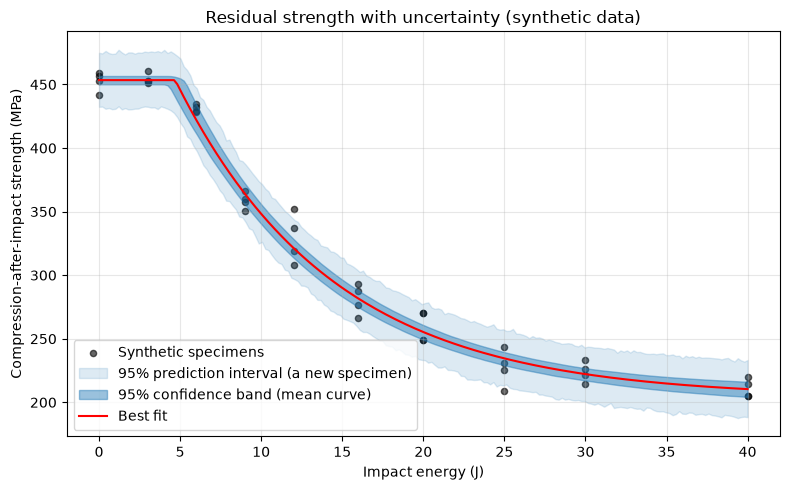

In [6]:
Eg = np.linspace(0, 40, 200)
ci_lo, ci_hi = confidence_band(Eg, boot)
pi_lo, pi_hi = prediction_interval(Eg, boot, resid_sd)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(E, S, color="k", alpha=0.6, s=20, label="Synthetic specimens")
ax.fill_between(Eg, pi_lo, pi_hi, color="tab:blue", alpha=0.15,
                label="95% prediction interval (a new specimen)")
ax.fill_between(Eg, ci_lo, ci_hi, color="tab:blue", alpha=0.45,
                label="95% confidence band (mean curve)")
ax.plot(Eg, predict_strength_from_energy(Eg, *best), "r-", label="Best fit")
ax.set_xlabel("Impact energy (J)")
ax.set_ylabel("Compression-after-impact strength (MPa)")
ax.set_title("Residual strength with uncertainty (synthetic data)")
ax.legend(loc="lower left")
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig("../figures/uncertainty_band.png", dpi=300)
plt.show()

In [7]:
lo_pts, hi_pts = prediction_interval(E, boot, resid_sd)
inside = np.mean((S >= lo_pts) & (S <= hi_pts))
print(f"{inside:.0%} of specimens fall inside the 95% prediction interval")

95% of specimens fall inside the 95% prediction interval


In [8]:
fraction = 0.70   # we want strength to stay above 70% of undamaged (a 30% knockdown)

E_allow = np.array([energy_for_strength_fraction(p, fraction) for p in boot])
E_allow = E_allow[~np.isnan(E_allow)]

E_best = energy_for_strength_fraction(best, fraction)
E_cons = np.percentile(E_allow, 5)
E_true = energy_for_strength_fraction([TRUE[n] for n in PARAM_NAMES], fraction)

print(f"Best estimate:   {E_best:.1f} J")
print(f"Conservative:    {E_cons:.1f} J  (about 95% confident the true limit is at least this)")
print(f"True value (hidden, synthetic): {E_true:.1f} J")

Best estimate:   12.3 J
Conservative:    11.7 J  (about 95% confident the true limit is at least this)
True value (hidden, synthetic): 12.9 J


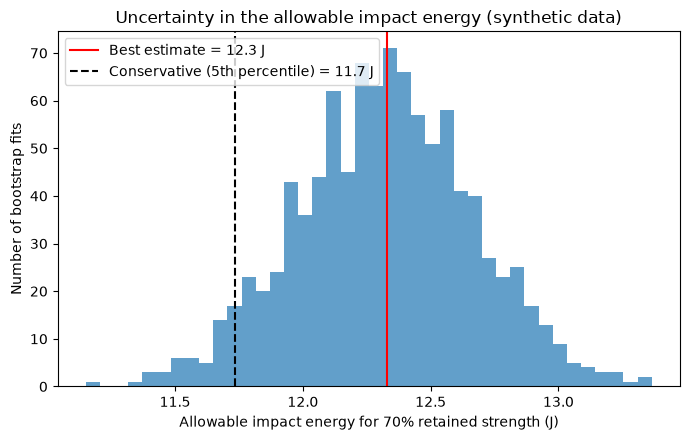

In [9]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(E_allow, bins=40, color="tab:blue", alpha=0.7)
ax.axvline(E_best, color="r", label=f"Best estimate = {E_best:.1f} J")
ax.axvline(E_cons, color="k", linestyle="--", label=f"Conservative (5th percentile) = {E_cons:.1f} J")
ax.set_xlabel("Allowable impact energy for 70% retained strength (J)")
ax.set_ylabel("Number of bootstrap fits")
ax.set_title("Uncertainty in the allowable impact energy (synthetic data)")
ax.legend()
fig.tight_layout()
fig.savefig("../figures/allowable_energy.png", dpi=300)
plt.show()

In [10]:
rows = []
for f in [0.6, 0.7, 0.8, 0.9]:
    vals = np.array([energy_for_strength_fraction(p, f) for p in boot])
    vals = vals[~np.isnan(vals)]
    rows.append({
        "min strength (fraction of undamaged)": f,
        "best estimate (J)": energy_for_strength_fraction(best, f),
        "conservative (J)": np.percentile(vals, 5),
    })
pd.DataFrame(rows).round(1)

,min strength (fraction of undamaged),best estimate (J),conservative (J)
0,0.6,17.3,16.4
1,0.7,12.3,11.7
2,0.8,9.1,8.6
3,0.9,6.6,6.2


In [11]:
rows = []
for f in [0.6, 0.7, 0.8, 0.9]:
    vals = np.array([energy_for_strength_fraction(p, f) for p in boot])
    vals = vals[~np.isnan(vals)]
    rows.append({
        "min strength (fraction of undamaged)": f,
        "best estimate (J)": energy_for_strength_fraction(best, f),
        "conservative (J)": np.percentile(vals, 5),
    })
pd.DataFrame(rows).round(1)

,min strength (fraction of undamaged),best estimate (J),conservative (J)
0,0.6,17.3,16.4
1,0.7,12.3,11.7
2,0.8,9.1,8.6
3,0.9,6.6,6.2
